In [159]:
import math 
import numpy as np
from matplotlib import pyplot as plt

## Derivatives 

### Derivative of a simple function with one input

In [160]:
def f(x):
    return x**2 + 3*x

x = 2
print('x =', x, '\nf(x) =', f(x))

# Derivative
h = 0.0001
d = (f(x+h) - f(x)) / h
print('Derivative:', d)

x = 2 
f(x) = 10
Derivative: 7.000100000027487


### Derivative of a function with multiple inputs

In [161]:
def f(a, b):
    return a**2 + a*b + b**2

a, b = 2, 3
fun = f(a, b)
print('a =', a, 'b =', b)
print('f(a, b) =', fun)

# Derivative
h = 0.0001
print("h =", h)

a += h
da = f(a, b)
print("Derivate wrt a", (da-fun)/h)

a -= h
b += h
db = (f(a, b))
print("Derivate wrt b", (db-fun)/h)

a = 2 b = 3
f(a, b) = 19
h = 0.0001
Derivate wrt a 7.000100000027487
Derivate wrt b 8.00009999998963


## Starting the core Value object of micrograd and its visualization

In [162]:
class Value:
    """ stores a single scalar value and it's gradient"""

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op 
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other): 
        out = Value(self.data + other.data, (self, other), "+")   # the last two parameters are used to tell the function it's parents (which are self and other)
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out 

    def tanh(self):
        x = self.data 
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out
    
a = Value(2.0, label='a')
b = Value(1.0, label='b')
c = Value(3.0, label='c')
d = Value(4.0, label='d')

# print(a)
# print(b)

e = a*b; e.label='e'    # This is equals to a.__mul__(b)
f = e + c; f.label='f'  # This is equals to a.__add__(b)
G = f + d; G.label='G'; 

# Updating gradients
G.grad = 1.0
d.grad = 1.0
f.grad = 1.0 
c.grad = 1.0
e.grad = 1.0
b.grad = 2.0
a.grad = 1.0


In [163]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

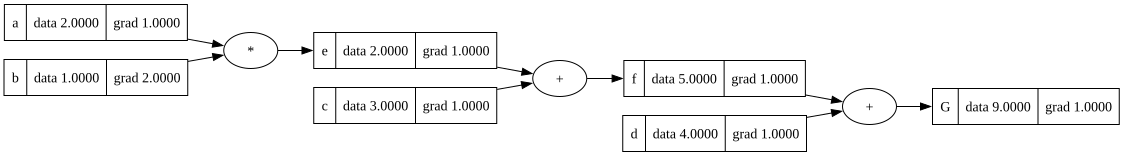

In [164]:
draw_dot(G)

### Manual backpropagation (finding gradients manually)

In [165]:
# G = f + d  
# dG/dd = 1 (therefore gradient of d will be f.data = 5)  
# similarly  
# dG/df = 1   

### Chain rule

In [166]:
# f = c + e
# df/dc = 1
# dG/dc =  (dG/df) * (df/dc) = 1 (therefore gradient of c will be 8) 

## Manual backpropagation on a neuron

In [167]:
# inputs x1,x2
x1 = Value(4.0, label='x1')
x2 = Value(5.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'         # tanh() is used to squeez the values between 0 and 1 

# Updating manually calculated grads 
o.grad  = 1
n.grad  = 0.9861
b.grad  = 0.9861

x2.grad = 0.9861
w2.grad = 4.9303

x1.grad = -2.9582
w1.grad = 3.9443

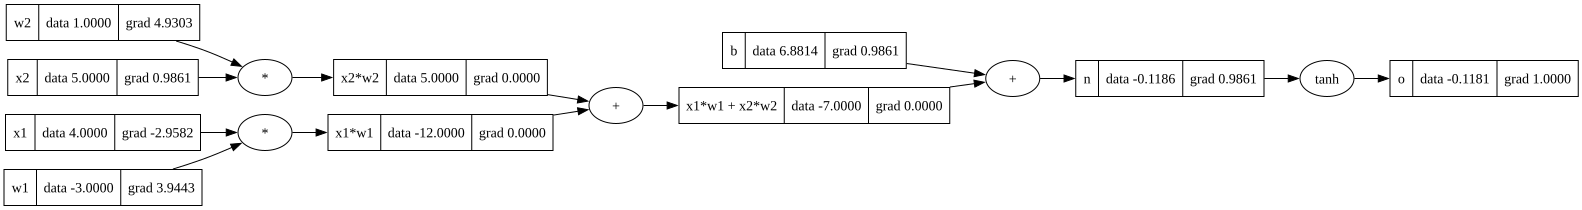

In [168]:
draw_dot(o)